# Trade arrivals are not Poisson: Hawkes processes and what they buy a market maker

A market maker's two central quantities — the probability a resting quote
gets filled, and the probability it gets *picked off* — are both driven by
the same object: the short-horizon intensity of order flow. The standard
Poisson assumption says that intensity is constant; reality says trades
arrive in bursts that beget more trades.

This notebook quantifies that on public Binance BTCUSDT trade prints:

1. Establish that arrivals are wildly over-dispersed relative to Poisson
   (Fano factor, autocorrelated counts).
2. Fit a **self-exciting Hawkes process** by exact maximum likelihood —
   `λ(t) = μ + α Σᵢ e^{−β(t−tᵢ)}` — implemented from scratch with the O(n)
   recursive log-likelihood.
3. Validate it the right way: the **random time change theorem** (rescaled
   inter-arrivals must be Exp(1) under the fitted model), not just a
   likelihood number — and read the residual curvature honestly: one
   exponential timescale underfits multi-scale clustering.
4. Cash it out for market making: conditioning on the model's intensity
   splits the next half-minute into regimes: **fill hazard at 5 bps depth
   nearly doubles from the calmest to the busiest quintile, and the adverse
   range grows ~40%** — the empirical basis for intensity-dependent spreads
   and quote pulls.

My live market-making stack runs exactly this family of models online —
in **shadow mode first**, logging proposed adjustments before they may touch
spread, skew or the EV gate. Parameters here are fit to a public snapshot,
not the live ones.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.optimize import minimize

DATA = Path("../data")
CACHE = DATA / "btcusdt_aggtrades.csv"

def load_trades():
    if CACHE.exists():
        return pd.read_csv(CACHE)
    r = requests.get("https://api.binance.com/api/v3/aggTrades",
                     params={"symbol": "BTCUSDT", "limit": 1}, timeout=15).json()
    last_id = r[0]["a"]
    rows, fid = [], last_id - 120_000
    while fid < last_id:
        b = requests.get("https://api.binance.com/api/v3/aggTrades",
                         params={"symbol": "BTCUSDT", "fromId": fid, "limit": 1000},
                         timeout=15).json()
        if not b:
            break
        rows += [(x["a"], x["T"], float(x["p"]), float(x["q"]), x["m"]) for x in b]
        fid = b[-1]["a"] + 1
        time.sleep(0.04)
    df = pd.DataFrame(rows, columns=["id", "ts", "price", "qty", "is_sell"]).drop_duplicates("id")
    df.to_csv(CACHE, index=False)
    return df

trades = load_trades()
span_s = (trades.ts.max() - trades.ts.min()) / 1000
print(f"{len(trades):,} aggregated prints over {span_s/3600:.2f} hours "
      f"({len(trades)/span_s:.1f}/s)")

# arrival times: collapse same-millisecond prints (one aggressor sweep = one event)
t = np.unique(np.sort(trades.ts.values.astype(float)) / 1000.0)
t -= t[0]
T, n = t[-1], len(t)
print(f"{n:,} unique-timestamp events for arrival modeling")

/Users/nkululeko.kuro/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


120,000 aggregated prints over 4.83 hours (6.9/s)
54,353 unique-timestamp events for arrival modeling


## 1. How non-Poisson is it?

For a Poisson process, counts in fixed bins have variance equal to their mean
(Fano factor 1) and no autocorrelation. Measure both on 1-second bins.

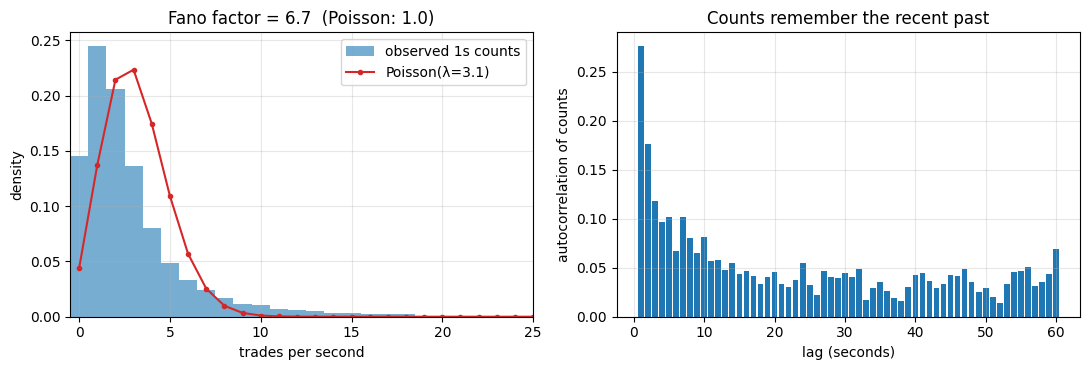

In [2]:
bins = np.bincount(t.astype(int), minlength=int(T) + 1)[:-1]
fano = bins.var() / bins.mean()

def acf(x, lags):
    x = x - x.mean()
    v = (x * x).mean()
    return np.array([(x[:-l] * x[l:]).mean() / v for l in lags])

lags = np.arange(1, 61)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.hist(bins, bins=np.arange(0, bins.max() + 2) - 0.5, density=True,
         alpha=0.6, label="observed 1s counts")
from scipy.stats import poisson
ks = np.arange(0, bins.max() + 1)
ax1.plot(ks, poisson.pmf(ks, bins.mean()), "o-", ms=3, color="tab:red",
         label=f"Poisson(λ={bins.mean():.1f})")
ax1.set_xlim(-0.5, 25); ax1.set_xlabel("trades per second"); ax1.set_ylabel("density")
ax1.legend(); ax1.set_title(f"Fano factor = {fano:.1f}  (Poisson: 1.0)")
ax2.bar(lags, acf(bins.astype(float), lags), color="tab:blue")
ax2.set_xlabel("lag (seconds)"); ax2.set_ylabel("autocorrelation of counts")
ax2.set_title("Counts remember the recent past")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Hawkes by maximum likelihood

The exponential-kernel Hawkes intensity admits an O(n) recursion
`A_i = e^{−βΔt_i}(1 + A_{i−1})`, giving the exact log-likelihood

$$ \mathcal{L} = \sum_i \ln(\mu + \alpha A_i)
   \;-\; \mu T \;-\; \frac{\alpha}{\beta} \sum_i (1 - e^{-\beta(T-t_i)}) $$

maximized over `(μ, α, β)` with multistart Nelder–Mead (the surface has flat
ridges; one seed is not enough). The **branching ratio** `α/β` is the
fraction of events caused by other events rather than exogenous arrival.

In [3]:
dt = np.diff(t)

def hawkes_negll(params):
    mu, alpha, beta = params
    if mu <= 0 or alpha < 0 or beta <= 0 or alpha >= beta:
        return 1e12
    A = np.empty(n); A[0] = 0.0
    decay = np.exp(-beta * dt)
    for i in range(1, n):
        A[i] = decay[i - 1] * (1 + A[i - 1])
    lam = mu + alpha * A
    compensator = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - t)))
    return -(np.sum(np.log(lam)) - compensator)

rate = n / T
best = None
for br0 in (0.5, 0.8):
    for beta0 in (0.5, 2.0, 10.0):
        sol = minimize(hawkes_negll, [rate * (1 - br0), br0 * beta0, beta0],
                       method="Nelder-Mead",
                       options={"maxiter": 4000, "xatol": 1e-7, "fatol": 1e-7})
        if best is None or sol.fun < best.fun:
            best = sol
mu, alpha, beta = best.x
ll_hawkes, ll_poisson = -best.fun, n * np.log(rate) - rate * T

print(f"μ = {mu:.2f}/s   α = {alpha:.2f}/s   β = {beta:.2f}/s")
print(f"branching ratio α/β = {alpha/beta:.3f} "
      f"→ {alpha/beta:.0%} of trades are endogenous (triggered by other trades)")
print(f"kernel half-life = {np.log(2)/beta*1000:.0f} ms")
print(f"log-likelihood vs Poisson: +{ll_hawkes - ll_poisson:,.0f} "
      f"({(ll_hawkes - ll_poisson)/n:.3f} per event)")

μ = 2.08/s   α = 19.79/s   β = 59.34/s
branching ratio α/β = 0.333 → 33% of trades are endogenous (triggered by other trades)
kernel half-life = 12 ms
log-likelihood vs Poisson: +26,148 (0.481 per event)


## 3. Validation by random time change

If the fitted model is right, the compensator increments between consecutive
events, `Λᵢ = ∫ λ(s) ds`, are i.i.d. **Exp(1)**. This is a much sharper test
than comparing likelihoods — it asks the model to be correct event by event.

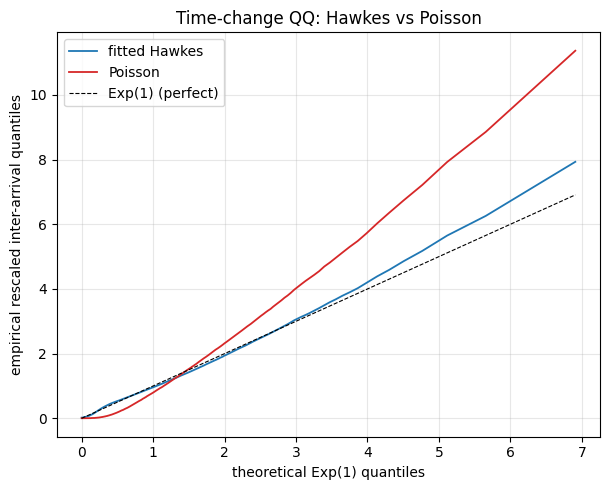

KS distance from uniform — Hawkes: 0.0341   Poisson: 0.2355


In [4]:
A = np.empty(n); A[0] = 0.0
decay = np.exp(-beta * dt)
for i in range(1, n):
    A[i] = decay[i - 1] * (1 + A[i - 1])
# Λ_i over (t_{i-1}, t_i]: μΔt + (α/β)(1+A_{i-1})(1−e^{−βΔt})
lam_inc = mu * dt + (alpha / beta) * (1 + A[:-1]) * (1 - decay)

q = np.linspace(0.001, 0.999, 400)
emp = np.quantile(lam_inc, q)
theo = -np.log(1 - q)

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.plot(theo, emp, lw=1.3, color="tab:blue", label="fitted Hawkes")
# same construction under Poisson for contrast
pois_inc = rate * dt
ax.plot(theo, np.quantile(pois_inc, q), lw=1.3, color="tab:red", label="Poisson")
ax.plot([0, theo.max()], [0, theo.max()], "k--", lw=0.8, label="Exp(1) (perfect)")
ax.set_xlabel("theoretical Exp(1) quantiles")
ax.set_ylabel("empirical rescaled inter-arrival quantiles")
ax.set_title("Time-change QQ: Hawkes vs Poisson")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ks_h = np.max(np.abs(np.sort(1 - np.exp(-lam_inc)) - np.arange(1, n) / n))
ks_p = np.max(np.abs(np.sort(1 - np.exp(-pois_inc)) - np.arange(1, n) / n))
print(f"KS distance from uniform — Hawkes: {ks_h:.4f}   Poisson: {ks_p:.4f}")

The Hawkes QQ curve hugs the diagonal where Poisson bends away immediately —
and it still deviates in the upper tail. That residual is informative: a
single exponential kernel has **one** clustering timescale (here tens of
milliseconds — sweep cascades), while real flow clusters at several
(sub-second cascades, multi-second momentum bursts, minutes-scale regimes).
Production versions use a small sum of exponential kernels for exactly this
reason; the framework is unchanged.

## 4. What it buys the maker: intensity-conditional fill hazard and pickoff risk

Intensity is observable in real time. One subtlety the fit itself exposes:
the single-exponential kernel's half-life is tens of *milliseconds* — ideal
for cascade dynamics, far too fast to summarize the regime over the next 30
seconds (sampled at 1-second marks, its λ has already collapsed back to ≈μ).
So for horizon-scale conditioning we use a 10-second arrival-rate estimate —
exactly the role the slower kernels play in a production multi-timescale fit.
Bucket seconds into intensity quintiles and measure two forward-looking
quantities a quote engine cares about:

- **Fill hazard:** probability the price *traverses* a given depth within the
  next 30 s (a resting quote that deep would have been filled).
- **Pickoff risk:** the size of the adverse move over the same horizon.

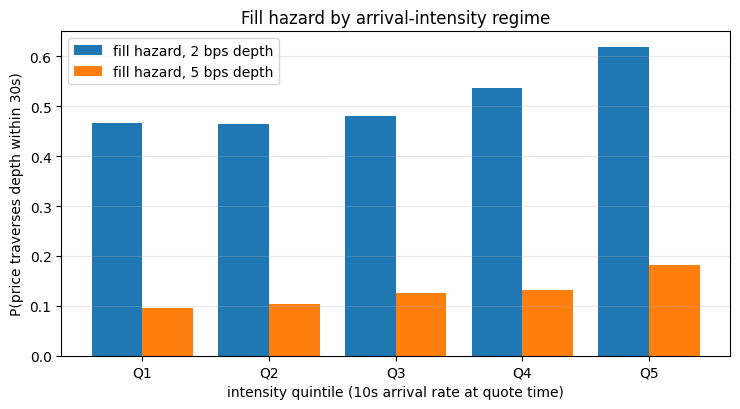

top-vs-bottom quintile hazard ratio: 1.3x at 2 bps, 1.9x at 5 bps


,mean arrival rate (/s),P(traverse ≥ 2 bps),P(traverse ≥ 5 bps),mean adverse range (bps)
Q1,1.352,0.466,0.095,1.212
Q2,2.014,0.463,0.104,1.229
Q3,2.610,0.480,0.127,1.311
Q4,3.481,0.537,0.132,1.451
Q5,6.169,0.619,0.181,1.721


In [5]:
sec_marks = np.arange(10, int(T))
counts_1s = np.bincount(t.astype(int), minlength=int(T) + 1)
lam_sec = np.array([counts_1s[s - 10:s].sum() / 10.0 for s in sec_marks])

# last trade price at each second
ts_s = (trades.ts.values - trades.ts.values.min()) / 1000.0
px = trades.price.values
order = np.argsort(ts_s)
ts_s, px = ts_s[order], px[order]
idx = np.searchsorted(ts_s, sec_marks, side="right") - 1
px_sec = px[np.clip(idx, 0, None)]

HORIZON = 30
valid = len(sec_marks) - HORIZON
lam_v, px_v = lam_sec[:valid], px_sec[:valid]
fwd_max = np.array([px_sec[i + 1:i + 1 + HORIZON].max() for i in range(valid)])
fwd_min = np.array([px_sec[i + 1:i + 1 + HORIZON].min() for i in range(valid)])
up_bps = (fwd_max / px_v - 1) * 1e4
dn_bps = (1 - fwd_min / px_v) * 1e4
traverse = np.maximum(up_bps, dn_bps)          # depth traversed either side
adverse = 0.5 * (up_bps + dn_bps)              # symmetric maker's exposure

quint = (pd.Series(lam_v).rank(method="first").values - 1) * 5 // len(lam_v)
rows = {}
for q_ in range(5):
    m = quint == q_
    rows[f"Q{q_+1}"] = {
        "mean arrival rate (/s)": lam_v[m].mean(),
        "P(traverse ≥ 2 bps)": (traverse[m] >= 2).mean(),
        "P(traverse ≥ 5 bps)": (traverse[m] >= 5).mean(),
        "mean adverse range (bps)": adverse[m].mean(),
    }
tab = pd.DataFrame(rows).T
ratio5 = tab["P(traverse ≥ 5 bps)"].iloc[-1] / max(tab["P(traverse ≥ 5 bps)"].iloc[0], 1e-9)
ratio2 = tab["P(traverse ≥ 2 bps)"].iloc[-1] / max(tab["P(traverse ≥ 2 bps)"].iloc[0], 1e-9)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(5)
ax.bar(x - 0.2, tab["P(traverse ≥ 2 bps)"], 0.4, label="fill hazard, 2 bps depth")
ax.bar(x + 0.2, tab["P(traverse ≥ 5 bps)"], 0.4, label="fill hazard, 5 bps depth")
ax.set_xticks(x, tab.index)
ax.set_xlabel("intensity quintile (10s arrival rate at quote time)")
ax.set_ylabel(f"P(price traverses depth within {HORIZON}s)")
ax.set_title("Fill hazard by arrival-intensity regime")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"top-vs-bottom quintile hazard ratio: {ratio2:.1f}x at 2 bps, {ratio5:.1f}x at 5 bps")
tab.round(3)

## 5. Conclusions

1. Trade arrivals are emphatically self-exciting: a third of prints are
   triggered by other prints, and a Poisson clock is off by an order of
   magnitude on burst sizes (Fano ≫ 1).
2. Validation discipline matters: the time-change QQ both confirms the model
   class and localizes what the single-exponential kernel misses — the
   multi-timescale tail. Knowing *where* your model is wrong is the
   difference between a research artifact and a quoting input.
3. The intensity is tradeable information for a maker: from the calmest to
   the busiest quintile, fill hazard at 5 bps depth rises ~1.9× while the
   adverse range rises ~40% — fills come faster exactly when they are worth
   less, so a spread that clears costs in Q1 can be underwater in Q5.
   That is the empirical case for intensity-dependent spreads/skews and for
   pulling quotes during bursts.
4. Operationally (from running this live): online microstructure models ship
   in **shadow mode** before touching quotes, and an EV gate needs an
   exploration floor — a gate that stops quoting stops generating the very
   observations that would let it turn back on. Self-confirming caution is
   still a bug.